In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

In [19]:
# https://archive.ics.uci.edu/dataset/53/iris

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
    header=None,
    encoding="utf-8",
)

# filtering
df = df[(df[4] == "Iris-setosa") | (df[4] == "Iris-versicolor")]

# mapping
df = df.replace({"Iris-setosa": 0, "Iris-versicolor": 1})

X = df[[0, 2]]
y = df[4]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

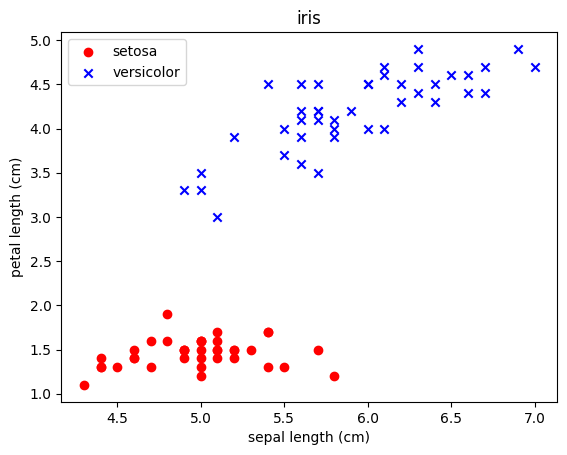

In [20]:
setosa_values = X_train[y_train == 0]
versicolor_values = X_train[y_train == 1]

plt.scatter(
    setosa_values.iloc[:, 0],
    setosa_values.iloc[:, 1],
    color="red",
    marker="o",
    label="setosa",
)
plt.scatter(
    versicolor_values.iloc[:, 0],
    versicolor_values.iloc[:, 1],
    color="blue",
    marker="x",
    label="versicolor",
)

plt.xlabel("sepal length (cm)")  # がく片
plt.ylabel("petal length (cm)")  # 花びら
plt.title("iris")

plt.legend()

plt.show()

In [21]:
model = Perceptron()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

mse = sklearn.metrics.mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

[1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Mean Squared Error: 0.0


[[3.3  0.  ]
 [3.32 0.  ]
 [3.34 0.  ]
 ...
 [7.94 6.08]
 [7.96 6.08]
 [7.98 6.08]]


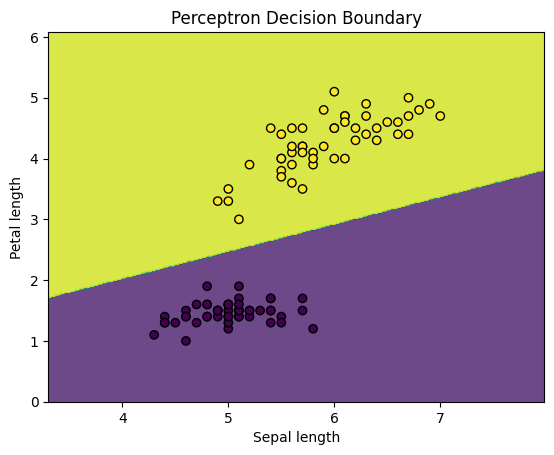

In [40]:
x_min, x_max = X[0].min() - 1, X[0].max() + 1
y_min, y_max = X[2].min() - 1, X[2].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[0], X[2], c=y, edgecolors="k")

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.title("Perceptron Decision Boundary")
plt.show()